In [1]:
from dsc80_utils import *

# Lecture 17 – Decision Trees and Random Forests

## DSC 80, Winter 2026

## Agenda 📆

- Decision trees.
- Grid search.
- Random forests.
- Modeling with text features.

## Decision trees 🌲

### Example: Predicting diabetes

In [2]:
diabetes = pd.read_csv(Path('data') / 'diabetes.csv')
display_df(diabetes, cols=9)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.63,50,1
1,1,85,66,29,0,26.6,0.35,31,0
2,8,183,64,0,0,23.3,0.67,32,1
...,...,...,...,...,...,...,...,...,...
765,5,121,72,23,112,26.2,0.24,30,0
766,1,126,60,0,0,30.1,0.35,47,1
767,1,93,70,31,0,30.4,0.32,23,0


### Exploring the dataset

First, a train-test split:

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(diabetes[['Glucose', 'BMI']], diabetes['Outcome'], random_state=1)
)

<span style='color: orange'><b>Class 0 (orange) is "no diabetes"</b></span> and <span style='color: blue'><b>class 1 (blue) is "diabetes"</b></span>.

In [4]:
fig = (
    X_train.assign(Outcome=y_train.astype(str))
            .plot(kind='scatter', x='Glucose', y='BMI', color='Outcome', 
                  color_discrete_map={'0': 'orange', '1': 'blue'},
                  title='Relationship between Glucose, BMI, and Diabetes')
)
fig

### Building a decision tree

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
dt = DecisionTreeClassifier(max_depth=2, criterion='entropy')
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

### Visualizing decision trees

Our fit decision tree is like a "flowchart", made up of a series of questions.

As before, <span style='color: orange'><b>orange is "no diabetes"</b></span> and <span style='color: blue'><b>blue  is "diabetes"</b></span>.

In [7]:
from sklearn.tree import plot_tree

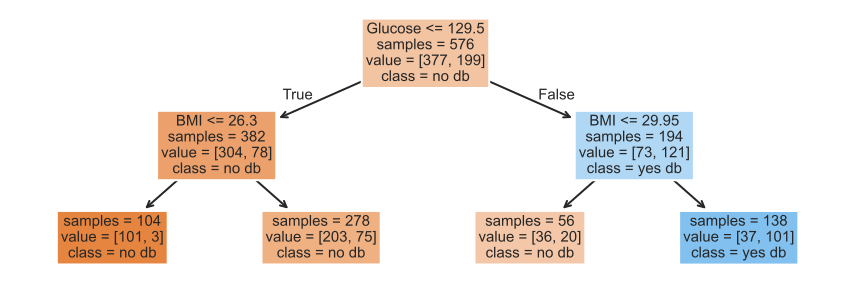

In [8]:
plt.figure(figsize=(15, 5))
plot_tree(dt, feature_names=X_train.columns, class_names=['no db', 'yes db'], 
          filled=True, fontsize=15, impurity=False);

- To **classify a new data point**, we start at the top and answer the first question (i.e. "Glucose <= 129.5").

- If the answer is "**Yes**", we move to the **left** branch, otherwise we move to the right branch.

- We repeat this process until we end up at a leaf node, at which point we predict the most common class in that node.
    - Note that each node has a `value` attribute, which describes the number of **training** individuals of each class that fell in that node.

In [9]:
# Note that the left node at depth 2 has a `value` of [304, 78].
y_train[X_train.query('Glucose <= 129.5').index].value_counts()

Outcome
0    304
1     78
Name: count, dtype: int64

### Evaluating classifiers

The most common evaluation metric in classification is **accuracy**:

$$\text{accuracy} = \frac{\text{\# data points classified correctly}}{\text{\# data points}}$$

In [10]:
(dt.predict(X_train) == y_train).mean()

0.765625

The `score` method of a classifier computes accuracy by default (just like the `score` method of a regressor computes $R^2$ by default). We want our classifiers to have **high accuracy**.

In [11]:
# Training accuracy – same number as above
dt.score(X_train, y_train)

0.765625

In [12]:
# Testing accuracy
dt.score(X_test, y_test)

0.7760416666666666

### Reflection

- Decision trees are easily interpretable: it is clear _how_ they make their predictions.

- They work with categorical data without needing to use one hot encoding.

- They also can be used in multi-class classification problems, e.g. when there are more than 2 possible outcomes.

- The _decision boundary_ of a decision tree can be arbitrarily complicated.

- **How are decision trees trained?**

### How are decision trees trained?

Pseudocode:

```python
def make_tree(X, y):
    if all points in y have the same label C:
        return Leaf(C)
    f = best splitting feature # e.g. Glucose or BMI
    v = best splitting value   # e.g. 129.5
    
    X_left, y_left   = X, y where (X[f] <= v)
    X_right, y_right = X, y where (X[f] > v)
    
    left  = make_tree(X_left, y_left)
    right = make_tree(X_right, y_right)
    
    return Node(f, v, left, right)
    
make_tree(X_train, y_train)
```

### How do we measure the quality of a split?

Our pseudocode for training a decision tree relies on finding the best way to "split" a node – that is, **the best question to ask** to help us narrow down which class to predict.

**Intuition**: Suppose the distribution within a node looks like this (colors represent classes):

<center>🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵🔵🔵</center>

Question A:
- "Yes": 🟠🟠🟠🔵🔵🔵
- "No": 🟠🟠🟠🔵🔵🔵🔵

Question B:
- "Yes": 🔵🔵🔵🔵🔵🔵
- "No": 🔵🟠🟠🟠🟠🟠🟠

**Which is the "better" question to ask?**

Question B, because there is "less uncertainty" in the resulting nodes. Let's try and quantify this!

### Entropy

- For each class $C$ within a node, define $p_C$ as the proportion of points with that class.
    - For example, the two classes may be "yes diabetes" and "no diabetes".

- The **surprise** of drawing a point from the node at random and having it be class $C$ is:

$$
\log_2 \left(\frac{1}{p_C}\right) = - \log_2 p_C
$$

- The **entropy** of a node is the expected (average) surprise over all classes:

\begin{align}
\text{entropy} &= - \sum_C p_C \log_2 p_C
\end{align}

- The entropy of 🟠🟠🟠🟠🟠🟠🟠🟠 is $ -1 \log_2(1) = 0 $.

- The entropy of 🟠🟠🟠🟠🔵🔵🔵🔵 is $ -0.5 \log_2(0.5) - 0.5 \log_2(0.5) = 1$.

- The entropy of 🟠🔵🟢🟡🟣 is $ - \log_2 \frac{1}{5} = \log_2(5) $
    - In general, if a node has $n$ points, all with different labels, the entropy of the node is $ \log_2(n) $.

### Example entropy calculation

Suppose we have:

<center>🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵🔵</center>

Question A:
- "Yes": 🟠🟠🟠🟠🟠🟠🔵
- "No": 🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵

Question B:
- "Yes": 🟠🟠🟠🟠🟠🟠🔵🔵🔵
- "No": 🟠🟠🟠🟠🟠🟠🔵🔵🔵

We choose to ask the question that has the lowest **weighted entropy**, that is:

$$\text{entropy of question} = \frac{\# \text{Yes}}{\# \text{Yes} + \# \text{No}} \cdot \text{entropy(Yes)} + \frac{\# \text{No}}{\# \text{Yes} + \# \text{No}} \cdot \text{entropy(No)}$$

In [13]:
def entropy(node):
    props = pd.Series(list(node)).value_counts(normalize=True)
    return -sum(props * np.log2(props))

In [14]:
entropy("🟠🟠🟠🟠🟠🟠🔵")

0.5916727785823275

In [15]:
def weighted_entropy(yes_node, no_node):
    yes_entropy = entropy(yes_node)
    no_entropy = entropy(no_node)
    yes_weight = len(yes_node) / (len(yes_node) + len(no_node))
    no_weight = 1 - yes_weight
    return yes_weight * yes_entropy + (no_weight) * no_entropy

In [16]:
# Question A:
weighted_entropy("🟠🟠🟠🟠🟠🟠🔵", "🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵")

0.8375578764623786

In [17]:
# Question B:
weighted_entropy("🟠🟠🟠🟠🟠🟠🔵🔵🔵", "🟠🟠🟠🟠🟠🟠🔵🔵🔵")

0.9182958340544896

Question A has the lower weighted entropy, so we'll use it.

### Understanding entropy

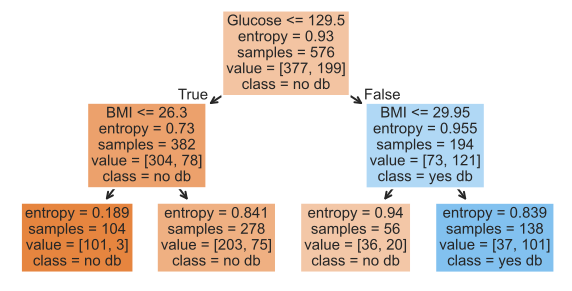

In [18]:
plt.figure(figsize=(10, 5))
plot_tree(dt, feature_names=X_train.columns, class_names=['no db', 'yes db'], 
          filled=True, fontsize=15, impurity=True);

We can recreate the entropy calculations in this tree.

In [19]:
# The leftmost node at the middle level has an entropy of 0.73,
# both displayed in the tree and verified here!
entropy([0] * 304 + [1] * 78)

0.7302263747422792

**Note:** The default `DecisionTreeClassifier` uncertaintly metric _isn't_ entropy, it is [Gini impurity](https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity). Our tree shows entropy because we set `criterion='entropy'` when defining `dt`. 

<div class="alert alert-warning">
    <h3>Question 🤔</h3>
</div>


(From Fa23 Final)

Suppose we fit decision trees of varying depths to predict 'y' using 'x1' and 'x2'. The entire training set is shown in the table below.

<center><img src='https://practice.dsc80.com/assets/images/fa23-final/dsc_80_final_q10.png' width=15%></center>

What is:

1. The entropy of a node containing all the training points.
1. The lowest possible entropy of a node in a fitted tree with depth 1 (two leaf nodes).
1. The lowest possible entropy of a node in a fitted tree with depth 2 (four leaf nodes).

### Tree depth

Decision trees are trained by **recursively** picking the best split until:

- all "leaf nodes" contain only training examples from a single class,
- it is impossible to split leaf nodes any further, or
- some other stopping criteria is reached.

By default, there are no additional stopping criteria, so decision trees tend to be very deep when unrestricted.

In [20]:
dt_no_max = DecisionTreeClassifier()
dt_no_max.fit(X_train, y_train)

DecisionTreeClassifier()

A decision tree fit on our training data is so deep that `tree.plot_tree` errors when trying to plot it.

In [21]:
dt_no_max.tree_.max_depth

20

At first, this tree seems "better" than our initial tree of depth 2, since its training accuracy is much much higher:

In [22]:
dt_no_max.score(X_train, y_train)

0.9913194444444444

In [23]:
# Depth 2 tree.
dt.score(X_train, y_train)

0.765625

But recall, we truly care about **test set performance**, and this decision tree has **worse accuracy on the test set than our depth 2 tree**.

In [24]:
dt_no_max.score(X_test, y_test)

0.7135416666666666

In [25]:
# Depth 2 tree.
dt.score(X_test, y_test)

0.7760416666666666

### Decision trees and overfitting

- Decision trees have a tendency to overfit. **Why is that?**

- Unlike linear classification techniques (like logistic regression or SVMs), **decision trees are non-linear**.
    - They are also "non-parametric", which means we don't need to make any assumptions about the underlying distribution of the data in nature.

- While being trained, decision trees ask enough questions to effectively **memorize** the correct response values in the training set. However, the relationships they learn are often **overfit** to the noise in the training set, and don't generalize well.

In [26]:
fig

- A decision tree whose depth is not restricted will achieve 100% accuracy on any training set, as long as there are no "overlapping values" in the training set.
    - Two values overlap when they have the same features $x$ but different response values $y$ (e.g. if two patients have the same glucose levels and BMI, but one has diabetes and one doesn't).

- **One solution to overfitting**: Make the decision tree "less complex" by limiting the maximum depth.

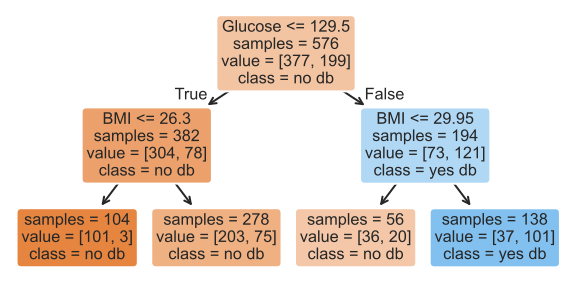

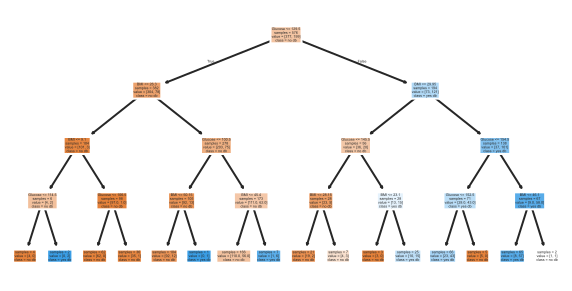

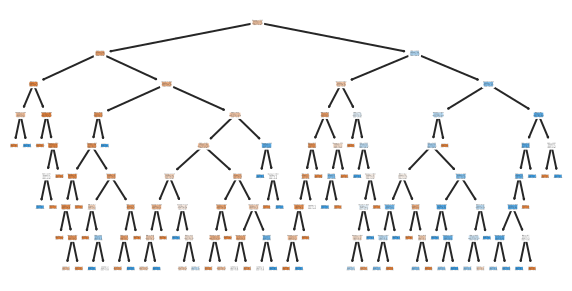

In [27]:
trees = {}
for d in [2, 4, 8]:
    trees[d] = DecisionTreeClassifier(max_depth=d, random_state=1)
    trees[d].fit(X_train, y_train)
    
    plt.figure(figsize=(10, 5), dpi=100)
    plot_tree(trees[d], feature_names=X_train.columns, class_names=['no db', 'yes db'], 
               filled=True, rounded=True, impurity=False)
    
    plt.show()

As tree depth increases, complexity increases, and our trees are more prone to overfitting. This means model bias decreases, but model variance increases. 

**Question**: What is the "right" maximum depth to choose?

### Hyperparameters for decision trees

- `max_depth` is a hyperparameter for `DecisionTreeClassifier`.

- There are many more hyperparameters we can tweak; look at [the documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) for examples.
    - `min_samples_split`: The minimum number of samples required to split an internal node.
    - `criterion`: The function to measure the quality of a split (`'gini'` or `'entropy'`).

- To ensure that our model generalizes well to unseen data, we need an efficient technique for trying different combinations of hyperparameters!

## Grid search 🔎

### Grid search

`GridSearchCV` takes in:
- an un-`fit` instance of an estimator, and
- a dictionary of hyperparameter values to try,

and performs $k$-fold cross-validation to find the **combination of hyperparameters** with the best average validation performance.

In [28]:
from sklearn.model_selection import GridSearchCV

The following dictionary contains the values we're considering for each hyperparameter. (We're using `GridSearchCV` with 3 hyperparameters, but we could use it with even just a single hyperparameter.)

In [29]:
hyperparameters = {
    'max_depth': [2, 3, 4, 5, 7, 10, 15, 20, 25, 50], 
    'min_samples_split': [2, 5, 10, 20, 50, 100, 200],
    'criterion': ['gini', 'entropy']
}

Note that there are 140 **combinations** of hyperparameters we need to try. We need to find the **best combination** of hyperparameters, not the best value for each hyperparameter individually.

In [30]:
len(hyperparameters['max_depth']) * \
len(hyperparameters['min_samples_split']) * \
len(hyperparameters['criterion'])

140

`GridSearchCV` needs to be instantiated and `fit`.

In [31]:
searcher = GridSearchCV(DecisionTreeClassifier(), hyperparameters, cv=5)

In [32]:
%%time
searcher.fit(X_train, y_train)

CPU times: user 1.24 s, sys: 7.8 ms, total: 1.25 s
Wall time: 1.26 s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 7, 10, 15, 20, 25, 50],
                         'min_samples_split': [2, 5, 10, 20, 50, 100, 200]})

After being `fit`, the `best_params_` attribute provides us with the best combination of hyperparameters to use.

In [33]:
searcher.best_params_

{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 50}

All of the intermediate results – validation accuracies for each fold, mean validation accuaries, etc. – are stored in the `cv_results_` attribute:

In [34]:
searcher.cv_results_['mean_test_score'] # Array of length 140.

array([0.73, 0.73, 0.73, ..., 0.75, 0.74, 0.72])

In [35]:
# Rows correspond to folds, columns correspond to hyperparameter combinations.
pd.DataFrame(np.vstack([searcher.cv_results_[f'split{i}_test_score'] for i in range(5)]))

,0,1,2,3,...,136,137,138,139
0,0.71,0.71,0.71,0.71,...,0.67,0.70,0.71,0.73
1,0.77,0.77,0.77,0.77,...,0.82,0.83,0.77,0.76
2,0.74,0.74,0.74,0.74,...,0.68,0.72,0.74,0.73
3,0.70,0.70,0.70,0.70,...,0.77,0.79,0.76,0.70
4,0.72,0.72,0.72,0.72,...,0.70,0.71,0.72,0.70


Note that the above DataFrame tells us that 5 * 140 = 700 models were trained in total!

Now that we've found the best combination of hyperparameters, we should fit a decision tree instance using those hyperparameters on our entire training set.

In [36]:
searcher.best_params_

{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 50}

In [37]:
final_tree = DecisionTreeClassifier(**searcher.best_params_)
final_tree

DecisionTreeClassifier(max_depth=4, min_samples_split=50)

In [38]:
final_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_split=50)

In [39]:
# Training accuracy.
final_tree.score(X_train, y_train)

0.7881944444444444

In [40]:
# Testing accuracy.
# A bit lower than the `dt` tree we fit above!
final_tree.score(X_test, y_test)

0.765625

Remember, `searcher` itself is a model object (we had to `fit` it). After performing $k$-fold cross-validation, behind the scenes, `searcher` is **automatically trained** on the entire training set using the optimal combination of hyperparameters.

In other words, `searcher` makes the same predictions that `final_tree` does!

In [41]:
searcher.score(X_train, y_train)

0.7881944444444444

In [42]:
searcher.score(X_test, y_test)

0.765625

### Choosing possible hyperparameter values

- A full grid search can take a **long time**.
    - In our previous example, we tried 140 combinations of hyperparameters.
    - Since we performed 5-fold cross-validation, we trained 700 decision trees under the hood.

- **Question**: How do we pick the possible hyperparameter values to try?

- **Answer**: Trial and error.
    - If the "best" choice of a hyperparameter was at an extreme, try increasing the range.
    - For instance, if you try `max_depth`s from 32 to 128, and 32 was the best, try including `max_depths` under 32.

### Key takeaways

- Decision trees are trained by finding the best questions to ask using the features in the training data. A good question is one that isolates classes as much as possible.
- Decision trees have a tendency to overfit to training data. One way to mitigate this is by restricting the maximum depth of the tree.
- To efficiently find hyperparameters through cross-validation, use `GridSearchCV`.
    - Specify which values to try for each hyperparameter, and `GridSearchCV` will try **all combinations of hyperparameters** and return the combination with the best average validation performance.
    - `GridSearchCV` is not the only solution – see [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) if you're curious.

### Decision tree pros and cons


✅ Pros:

- Relatively fast to train and make predictions.
    - Making predictions: $O(\text{tree depth})$, which is usually $O(\log n)$.
- Easily interpretable.
- Robust to irrelevant features – why?
- Works with categorical and numerical data. Doesn't require much preprocessing (feature engineering).
  
❌ Cons:

- High variance: with no limitations (e.g. `max_depth`), will almost always overfit!
- Creates biased predictions if classes are unbalanced.
- Not the best at prediction in general (sensitive to outliers and noise in the training data, not good at extrapolating outside of the training data).

[`sklearn`'s documentation](https://scikit-learn.org/stable/modules/tree.html) provides a good overview of the pros and cons of decision trees.



## Random Forests

### Another idea: 

Train a bunch of decision trees, then have them **vote** on a prediction!

<center><img src='imgs/random_forest.png' width=75%></center>

- **Problem:** If you use the same training data, you will always get the same tree.
- **Solution:** Introduce randomness into training procedure to get different trees.

### Idea 1: Bootstrap the training data

- We can bootstrap the training data $T$ times, then train one tree on each resample.
- Also known as bagging (Bootstrap AGgregating). In general, combining different predictors together is a useful technique called **ensemble learning**.
- For decision trees though, this doesn't make the trees different enough from each other (e.g. if you have one really strong predictor, it will always be the first split).

### Idea 2: At each split, use a subset of features

- At each split, take a random subset of $ m $ features instead of choosing from all $ d $ of them.
- Rule of thumb: $ m \approx \sqrt d $ seems to work well.
- Key idea: For ensemble learning, you want the individual predictors to have low bias, high variance, and be uncorrelated with each other. That way, when you average them together, you have low bias AND low variance.

- **Random forest algorithm:** Fit $ T $ trees by using bagging and a random subset of features at each split. Predict by taking a vote from the $ T $ trees.

<div class="alert alert-warning">
    <h3>Question 🤔</h3>
</div>

How will increasing $ m $ affect the bias / variance of each decision tree?

## Example

In [43]:
# Let's use more features for prediction
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(diabetes.drop(columns=['Outcome']), diabetes['Outcome'], random_state=1)
)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf.score(X_train, y_train)

1.0

In [45]:
rf.score(X_test, y_test)

0.8020833333333334

This is better than our best single decision tree from earlier.

## Example: Modeling using text features

### Example: Fake news

We have a dataset ([source](https://github.com/KaiDMML/FakeNewsNet)) containing news articles and labels for whether the article was deemed "fake" or "real".

In [46]:
news = pd.read_csv('data/fake_news_training.csv')
news

,baseurl,content,label
0,twitter.com,\njavascript is not available.\n\nwe’ve detect...,real
1,whitehouse.gov,remarks by the president at campaign event -- ...,real
2,web.archive.org,the committee on energy and commerce\nbarton: ...,real
...,...,...,...
658,politico.com,full text: jeff flake on trump speech transcri...,fake
659,pol.moveon.org,moveon.org political action: 10 things to know...,real
660,uspostman.com,"uspostman.com is for sale\nyes, you can transf...",fake


**Goal**: Use an article's content to predict its label.

In [47]:
news['label'].value_counts(normalize=True)

label
real    0.55
fake    0.45
Name: proportion, dtype: float64

**Question**: What is the worst possible accuracy we should expect from a classifier, given the above distribution?

### Aside: `CountVectorizer`

Entries in the `'content'` column are not currently quantitative! We can use the bag of words encoding to create quantitative features out of each `'content'`.

 Instead of performing a bag of words encoding manually as we did before, we can rely on `sklearn`'s `CountVectorizer`. (There is also a `TfidfVectorizer`.)

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

In [49]:
nursery_rhymes = ['Jack be nimble, Jack be quick, Jack jump over the candlestick.', 
                  'Jack and Jill went up the hill to fetch a pail of water.',
                  'Little Jack Horner sat in the corner eating a Christmas pie.']

In [50]:
count_vec = CountVectorizer()
count_vec.fit(nursery_rhymes)

CountVectorizer()

`count_vec` learned a **vocabulary** from the corpus we `fit` it on.

In [51]:
count_vec.vocabulary_

{'jack': 10,
 'be': 1,
 'nimble': 14,
 'quick': 19,
 'jump': 12,
 'over': 16,
 'the': 21,
 'candlestick': 2,
 'and': 0,
 'jill': 11,
 'went': 25,
 'up': 23,
 'hill': 7,
 'to': 22,
 'fetch': 6,
 'pail': 17,
 'of': 15,
 'water': 24,
 'little': 13,
 'horner': 8,
 'sat': 20,
 'in': 9,
 'corner': 4,
 'eating': 5,
 'christmas': 3,
 'pie': 18}

In [52]:
count_vec.transform(nursery_rhymes).toarray()

array([[0, 2, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]])

Note that  `count_vec.vocabulary_` is a dictionary that maps each word to the associated column in the array above. For example, the first column corresponds to `'and'`.

In [53]:
nursery_rhymes

['Jack be nimble, Jack be quick, Jack jump over the candlestick.',
 'Jack and Jill went up the hill to fetch a pail of water.',
 'Little Jack Horner sat in the corner eating a Christmas pie.']

In [54]:
pd.DataFrame(count_vec.transform(nursery_rhymes).toarray(),
             columns=pd.Series(count_vec.vocabulary_).sort_values().index)

,and,be,candlestick,christmas,...,to,up,water,went
0,0,2,1,0,...,0,0,0,0
1,1,0,0,0,...,1,1,1,1
2,0,0,0,1,...,0,0,0,0


### Creating an initial `Pipeline`

Let's build a `Pipeline` that takes in summaries and overall ratings and:

- Uses `CountVectorizer` to quantitatively encode summaries.

- Fits a `RandomForestClassifier` to the data.

But first, a train-test split (like **always**).

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [56]:
X = news['content']
y = news['label']
X_train, X_test, y_train, y_test = train_test_split(X, y)

To start, we'll create a random forest with 100 trees (`n_estimators`) each of which has a maximum depth of 3 (`max_depth`).

In [57]:
pl = Pipeline([
    ('bag-of-words', CountVectorizer()), 
    ('forest', RandomForestClassifier(
        max_depth=3,
        n_estimators=100, # Uses 100 separate decision trees!
        random_state=42,
    )) 
])

In [58]:
pl.fit(X_train, y_train)

Pipeline(steps=[('bag-of-words', CountVectorizer()),
                ('forest',
                 RandomForestClassifier(max_depth=3, random_state=42))])

In [59]:
# Training accuracy.
pl.score(X_train, y_train)

0.7919191919191919

In [60]:
# Testing accuracy.
pl.score(X_test, y_test)

0.6867469879518072

The accuracy of our random forest is just under 70%, on the test set. How much better does it do compared to a classifier that predicts "real" every time?

In [61]:
y_train.value_counts(normalize=True)

label
real    0.58
fake    0.42
Name: proportion, dtype: float64

In [62]:
# Distribution of predicted ys in the training set:

# stops scientific notation for pandas
pd.set_option('display.float_format', '{:.3f}'.format)
pd.Series(pl.predict(X_train)).value_counts(normalize=True)

fake   0.547
real   0.453
Name: proportion, dtype: float64

### Choosing tree depth via `GridSearchCV`

We arbitrarily chose `max_depth=3` before, but it seems like that isn't working well. Let's perform a grid search to find the `max_depth` with the best generalization performance.

In [63]:
# Note that we've used the key forest__max_depth, not max_depth
# because max_depth is a hyperparameter of the step we called "forest".
# It is not a hyperparameter of the pipeline, pl.

hyperparameters = {
    'forest__max_depth': np.arange(2, 200, 20)
}

Note that while `pl` has already been `fit`, we can still give it to `GridSearchCV`, which will repeatedly re-`fit` it during cross-validation.

In [64]:
%%time

# Takes a few seconds to run – how many trees are being trained?
from sklearn.model_selection import GridSearchCV
grids = GridSearchCV(
    pl,
    n_jobs=-1, # Use multiple processors to parallelize
    param_grid=hyperparameters,
    return_train_score=True
)
grids.fit(X_train, y_train)

/Users/msgol/ENTER/envs/dsc80/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning:

invalid value encountered in cast



CPU times: user 1.44 s, sys: 267 ms, total: 1.71 s
Wall time: 8.61 s


GridSearchCV(estimator=Pipeline(steps=[('bag-of-words', CountVectorizer()),
                                       ('forest',
                                        RandomForestClassifier(max_depth=3,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'forest__max_depth': array([  2,  22,  42,  62,  82, 102, 122, 142, 162, 182])},
             return_train_score=True)

In [65]:
grids.best_params_

{'forest__max_depth': 42}

Recall, `fit` `GridSearchCV` objects are estimators on their own as well. This means we can compute the training and testing accuracies of the "best" random forest directly:

In [66]:
# Training accuracy.
grids.score(X_train, y_train)

0.9919191919191919

In [67]:
# Testing accuracy.
grids.score(X_test, y_test)

0.7951807228915663

In [68]:
# Compare to our original model with max_depth = 3.
pl.score(X_test, y_test)

0.6867469879518072

~15% better test set error!

### Training and validation accuracy vs. depth

Below, we plot how training and validation accuracy varied with tree depth. Note that the $y$-axis here is accuracy, and that larger accuracies are better (unlike with RMSE, where smaller was better).

In [69]:
index = grids.param_grid['forest__max_depth']
train = grids.cv_results_['mean_train_score']
valid = grids.cv_results_['mean_test_score']

In [70]:
pd.DataFrame({'train': train, 'valid': valid}, index=index).plot().update_layout(
    xaxis_title='max_depth', yaxis_title='Accuracy'
)

<div class="alert alert-warning">
    <h3>Question 🤔</h3>
</div>

(From Fa23 Final)
    
Suppose we write the following code:

```python
hyperparameters = {
    'n_estimators': [10, 100, 1000], # number of trees per forest
    'max_depth': [None, 100, 10]     # max depth of each tree
}
grids = GridSearchCV(
    RandomForestClassifier(), param_grid=hyperparameters,
    cv=3, # 3-fold cross-validation
)
grids.fit(X_train, y_train)
```

Answer the following questions with a single number.

1. How many random forests are fit in total?
1. How many decision trees are fit in total?
1. How many times in total is the first point in `X_train` used to train a decision tree?

## Classifier Evaluation

### Accuracy isn't everything!

$$
\text{accuracy} = \frac{\text{\# data points classified correctly}}{\text{\# data points}}
$$

* Accuracy is defined as the proportion of predictions that are correct.

* It weighs all **correct** predictions the same, and weighs all **incorrect** predictions the same.

* But some incorrect predictions may be worse than others!
    - Example: **diagnosing a disease** when a person doesn't have it vs. **not diagnosing a disease** when a person does have it.


### The Boy Who Cried Wolf 👦😭🐺 

([source](https://en.wikipedia.org/wiki/The_Boy_Who_Cried_Wolf))

> The tale concerns a shepherd boy who repeatedly tricks villagers into believing a wolf is attacking his flock. When a real wolf appears and the boy cries for help, the villagers dismiss it as another false alarm, allowing the wolf to devour the sheep.

### The wolf classifier

* Predictor: Shepherd boy.
* Positive prediction: "There is a wolf."
* Negative prediction: "There is no wolf."

Some questions to think about:

- What is an example of an incorrect, positive prediction?

- Was there a correct, negative prediction?

- There are four possibilities. What are the consequences of each?
    - (predict yes, predict no) x (actually yes, actually no). 

### Outcomes in binary classification

When performing **binary** classification, there are four possible outcomes. 

|Outcome of Prediction|Definition|True Class|
|---|---|---|
|**True** positive (TP) ✅|The predictor **correctly** predicts the positive class.|P|
|False negative (FN) ❌|The predictor incorrectly predicts the negative class.|P|
|**True** negative (TN) ✅|The predictor **correctly** predicts the negative class.|N|
|False positive (FP) ❌|The predictor incorrectly predicts the positive class.|N|

<center>⬇️</center>

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN ✅ | FP ❌ |
| **Actually Positive** | FN ❌ | TP ✅ |

<br>

The <b>confusion matrix</b> above summarizes the four possibilities.

Note that in the four acronyms – TP, FN, TN, FP – the **first letter** is whether the prediction is correct, and the **second letter** is what the prediction is.

### Example: Measles outbreak 🔴

- Measles is a highly contagious disease that can cause severe illness. The number of measles cases in the US has surged in recent months.

<center><img src="imgs/measles.jpg" width=75%></center>

- Tests exist to identify active measles infections. Tests can come back
    - positive, indicating that the individual has measles, or
    - negative, indicating that the individual does not have measles.

<div class="alert alert-warning">
    <h3>Question 🤔</h3>
</div>

What is a TP in this scenario? FP? TN? FN?

### Accuracy of measles tests

The results of 100 measles tests are given below.

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN = 90 ✅ | FP = 1 ❌ |
| **Actually Positive** | FN = 8 ❌ | TP = 1 ✅ |

🤔 **Question:** What is the accuracy of the test?

**🙋 Answer:** $$\text{accuracy} = \frac{TP + TN}{TP + FP + FN + TN} = \frac{1 + 90}{100} = 0.91$$

- **Followup:** At first, the test seems good. But, suppose we build a classifier that predicts that **nobody has measles**. What would its accuracy be?

- **Answer to followup:** Also 0.91! There is severe **class imbalance** in the dataset, meaning that most of the data points are in the same class (no measles). Accuracy doesn't tell the full story.

### Recall

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN = 90 ✅ | FP = 1 ❌ |
| <span style='color:orange'><b>Actually Positive</b></span> | <span style='color:orange'>FN = 8</span> ❌ | <span style='color:orange'>TP = 1</span> ✅ |

🤔 **Question:** What proportion of individuals who actually have measles did the test **identify**?

**🙋 Answer:** $\frac{1}{1 + 8} = \frac{1}{9} \approx 0.11$

More generally, the **recall** of a binary classifier is the proportion of <span style='color:orange'><b>actually positive instances</b></span> that are correctly classified. We'd like this number to be as close to 1 (100%) as possible.

$$\text{recall} = \frac{TP}{\text{\# actually positive}} = \frac{TP}{TP + FN}$$

To compute recall, look at the <span style='color:orange'><b>bottom (positive) row</b></span> of the above confusion matrix.

### Recall isn't everything, either!

$$\text{recall} = \frac{TP}{TP + FN}$$

🤔 **Question:** Can you design a "measles test" with perfect recall?

**🙋 Answer:** Yes – **just predict that everyone has measles!**

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN = 0 ✅ | FP = 91 ❌ |
| <span style='color:orange'><b>Actually Positive</b></span> | <span style='color:orange'>FN = 0</span> ❌ | <span style='color:orange'>TP = 9</span> ✅ |

<center><i><small>everyone-has-measles classifier</small></i></center>


$$\text{recall} = \frac{TP}{TP + FN} = \frac{9}{9 + 0} = 1$$

Like accuracy, recall on its own is not a perfect metric. Even though the classifier we just created has perfect recall, it has 91 false positives!

### Precision

| | Predicted Negative | <span style='color:orange'>Predicted Positive</span> |
| --- | --- | --- |
| **Actually Negative** | TN = 0 ✅ | <span style='color:orange'>FP = 91</span> ❌ |
| **Actually Positive** | FN = 0 ❌ | <span style='color:orange'>TP = 9</span> ✅ |

<center><i><small>everyone-has-measles classifier</small></i></center>


The **precision** of a binary classifier is the proportion of <span style='color:orange'><b>predicted positive instances</b></span> that are correctly classified. We'd like this number to be as close to 1 (100%) as possible.

$$\text{precision} = \frac{TP}{\text{\# predicted positive}} = \frac{TP}{TP + FP}$$

To compute precision, look at the <span style='color:orange'><b>right (positive) column</b></span> of the above confusion matrix.

- **Tip:** A good way to remember the difference between precision and recall is that in the denominator for 🅿️recision, both terms have 🅿️ in them (TP and FP).

- Note that the "everyone-has-measles" classifier has perfect recall, but a precision of $\frac{9}{9 + 91} = 0.09$, which is quite low.

- 🚨 **Key idea:** There is a "tradeoff" between precision and recall. Ideally, you want both to be high. For a particular prediction task, one may be important than the other.

### Precision and recall

$$\text{precision} = \frac{TP}{TP + FP} \: \: \: \:  \: \: \: \: \text{recall} = \frac{TP}{TP + FN}$$

<div class="alert alert-warning">
    <h3>Question</h3>
</div>

- When might high **precision** be more important than high recall?

- When might high **recall** be more important than high precision?

### Precision and recall

<center><img src="imgs/Precisionrecall.svg.png" width=30%></center>

<center>(<a href="https://en.wikipedia.org/wiki/Precision_and_recall">source</a>)</center>

<div class="alert alert-warning">
    <h3>Question 🤔</h3>
</div>

Consider the confusion matrix shown below.

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN = 22 ✅ | FP = 2 ❌ |
| **Actually Positive** | FN = 23 ❌ | TP = 18 ✅ |

What is the accuracy of the above classifier? The precision? The recall?

## Summary, next time

### Summary

- Decision trees, while interpretable, are prone to having high variance. There are several ways to control the variance of a decision tree:
    - Limit `max_depth` or increase `min_samples_split`.
    - Create a random forest, which is an ensemble of multiple decision trees, each fit to a different random resample of the training data, using a random sample of features.
- In order to tune model hyperparameters – that is, to find the hyperparameters that likely maximize performance on unseen data – use `GridSearchCV`.
- Accuracy alone is not always a meaningful representation of a classifier's quality, particularly when the classes are imbalanced.
    - Precision and recall are classifier evaluation metrics that consider the types of errors being made.
    - There is a "tradeoff" between precision and recall. One may be more important than the other, depending on the task.

### Next time

We'll continue our discussion of evaluating classifiers and talk about model fairness, which is part of your Final Project.